# Mushroom Safety Classification

Dataset: 8781 mushroom images across 4 safety classes

    - Edible
    - Conditionally Edible
    - Poisonous
    - Deadly

## Project Overview

This project aimed to classify mushroom images into four safety categories: 'Edible', 'Conditionally Edible', 'Poisonous', and 'Deadly'. The primary challenge identified was the low recall for the 'Deadly' class, which is critical for a safety-sensitive application.


### Initial Approach: Custom CNN

An initial custom Convolutional Neural Network (CNN) model was built and trained. While it achieved an overall accuracy of approximately 85%, the recall for the 'Deadly' class was only 64%. This indicated a significant risk, as nearly one-third of deadly mushrooms were not being correctly identified.


### First Improvement Attempt: Transfer Learning with Frozen ResNet50

To improve performance, especially for the 'Deadly' class, Transfer Learning was implemented using a pre-trained ResNet50 model. The base layers of ResNet50 were frozen, and custom classification layers were added on top. However, this approach unexpectedly *decreased* the recall for the 'Deadly' class to 20% and reduced overall accuracy to 66%. This suggested that the frozen, general features from ImageNet were not well-suited for the specific nuances of mushroom classification, particularly given the visual similarities between 'deadly' and 'poisonous' species.


### Second Improvement Attempt: Class Weighting and Deeper Fine-tuning

Recognizing the severe class imbalance and the suboptimal performance of the frozen model, a revised strategy was adopted:

1.  **Class Weighting:** To address the underrepresentation of the 'Deadly' class, class weights were calculated and applied during training, giving higher importance to misclassifications of minority classes.
2.  **Deeper Fine-tuning:** More layers of the ResNet50 base model (starting from layer 50) were unfrozen, allowing the model to adapt more of its feature extraction capabilities to the mushroom dataset. A very low learning rate was used for stability during this fine-tuning phase.

This improved approach resulted in a slight increase in overall accuracy to 67% but still showed low recall (16%) for the 'deadly' class, indicating that ResNet50, even with deeper fine-tuning and class weighting, struggled with this specific dataset and its challenges.


### Final Strategy: EfficientNetV2-B0 with Learning Rate Scheduling and Early Stopping

To achieve higher accuracy and significantly improve 'Deadly' class recall, a more advanced transfer learning architecture was implemented:

1.  **EfficientNetV2-B0:** This model was chosen for its superior efficiency and accuracy compared to ResNet50.
2.  **Fine-tuning:** The top 50 layers of EfficientNetV2-B0 were unfrozen for fine-tuning.
3.  **Learning Rate Scheduling and Early Stopping:** These callbacks were used to prevent overfitting and optimize training, allowing the model to converge effectively.
4.  **Class Weighting:** Continued to be applied to mitigate class imbalance.

This final model achieved an overall accuracy of **85.49%** on the test set. Crucially, the recall for the 'Deadly' class improved significantly to **83%**, demonstrating that the model was much better at identifying potentially fatal mushrooms. The precision for the 'Deadly' class was 68%, indicating some over-prediction to ensure deadly mushrooms are not missed, which is acceptable for a safety-critical application.


### Conclusion

The EfficientNetV2-B0 model with class weighting, learning rate scheduling, and fine-tuning proved to be the most effective strategy. While the overall accuracy returned to the level of the initial custom CNN, the critical improvement in 'Deadly' class recall (from 64% to 83%) makes this model far more suitable for its intended safety-critical purpose. Further optimizations, such as increasing input resolution, synthetic over-sampling, or implementing Focal Loss, could potentially push accuracy even higher and refine precision without sacrificing recall.

In [ ]:
!pip install -q tensorflow

# import libraries

# provide operating system dependent functionality
import os
from pathlib import Path

# provide support for mathematical functions
import numpy as np

# provide data visualisations
import matplotlib.pyplot as plt
import seaborn as sns

# provide training for neural networks and build deep learning models
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model

# provide functions for preprocessing data
import tensorflow.keras.utils

# evaluate the performance of the deep learning model
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## View the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = "/content/drive/MyDrive/CN7023 - Artificial Intelligence & Machine Vision/Coursework/mushroom_dataset"

In [ ]:
# look at dataset folder structure

mushroom_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    df,
    image_size=(100, 100),
    batch_size=32,
    label_mode="int"
)

Found 8781 files belonging to 4 classes.


In [ ]:
# view class names

print(f"Number and names of classes found: {len(mushroom_dataset.class_names)}")

print(mushroom_dataset.class_names)

Number and names of classes found: 4
['conditionally_edible', 'deadly', 'edible', 'poisonous']


In [ ]:
len(mushroom_dataset)

275

In [ ]:
# find number of images in each class

import pandas as pd

class_counts = {}

# include each class directory

for class_name in mushroom_dataset.class_names:
    class_path = os.path.join(df, class_name)
    count = 0
    if os.path.isdir(class_path):
        # count all image files in the class directory and its subdirectories
        for root, dirs, files in os.walk(class_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    count += 1
    class_counts[class_name] = count

# convert to a pandas DataFrame
counts_df = pd.DataFrame(class_counts.items(), columns=['Class', 'Image Count'])

display(counts_df)

,Class,Image Count
0,conditionally_edible,420
1,deadly,1190
2,edible,2475
3,poisonous,4696


## Display a random sample of images from the entire dataset

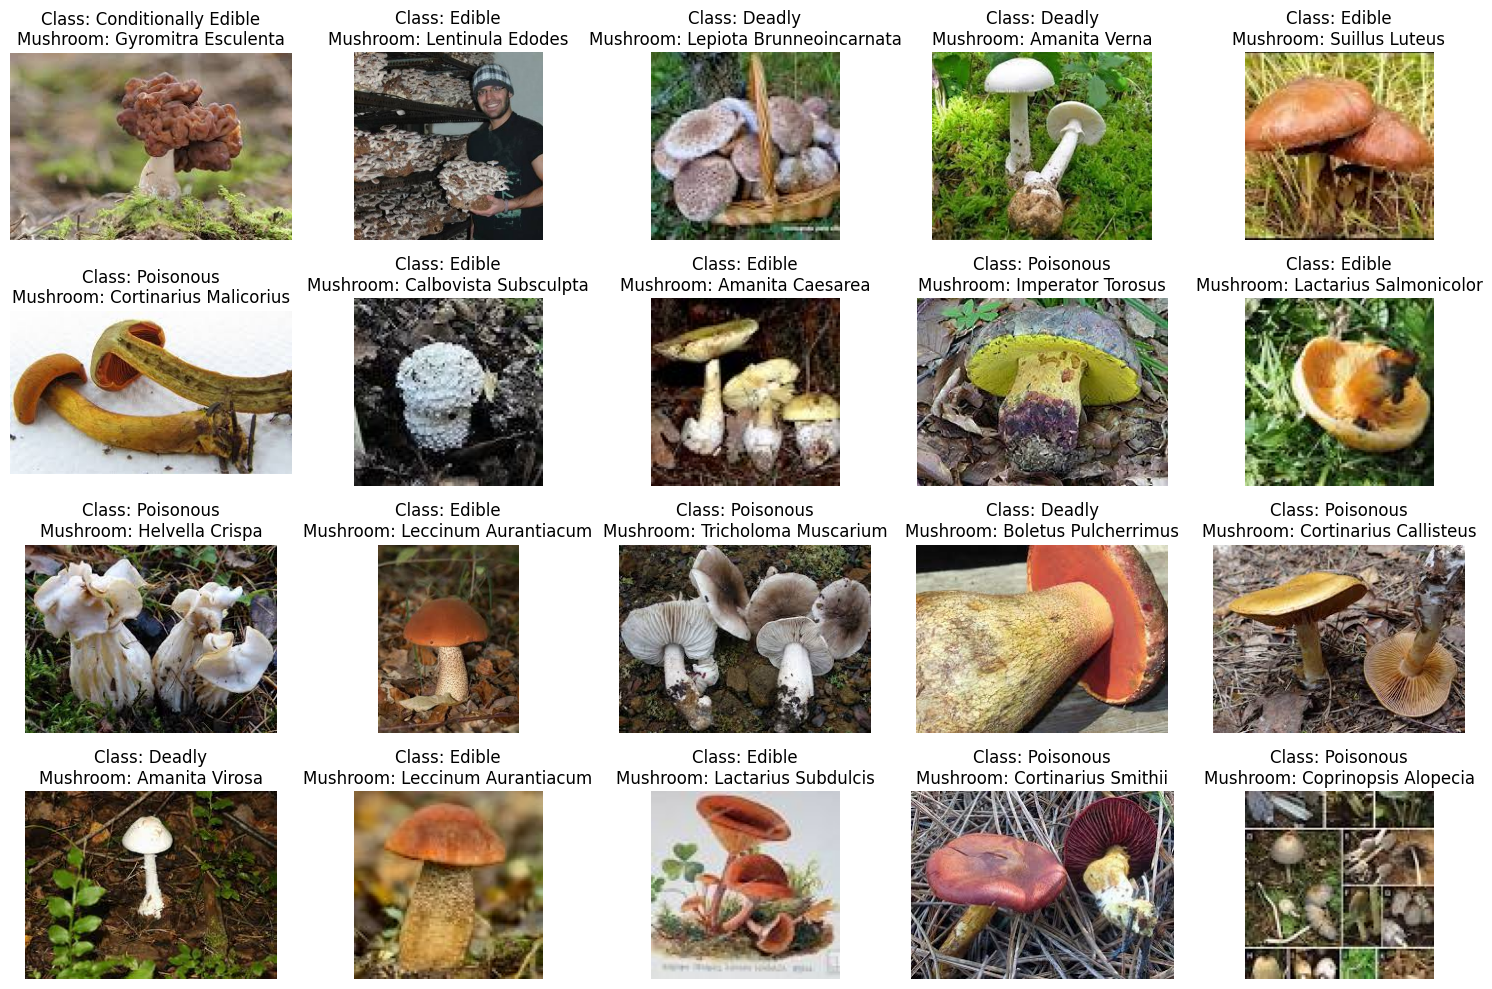

In [ ]:
import random

all_image_paths = []

# find all image files in the dataset directory
for root, dirs, files in os.walk(df):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            all_image_paths.append(os.path.join(root, file))

# choose a random sample of images
num_samples = 20
random_sample_paths = random.sample(all_image_paths, min(num_samples, len(all_image_paths)))

plt.figure(figsize=(15, 10))
ncols = 5
nrows = (len(random_sample_paths) + ncols - 1) // ncols

for i, img_path in enumerate(random_sample_paths):
    img = tf.keras.preprocessing.image.load_img(img_path)
    plt.subplot(nrows, ncols, i + 1)
    plt.imshow(img)

    # extract class name and mushroom type from the path
    path_parts = Path(img_path).parts

    try:
        class_name_idx = path_parts.index(os.path.basename(df)) + 1
        class_name = path_parts[class_name_idx].replace('_', ' ').title()
        mushroom_type = path_parts[class_name_idx + 1].replace('_', ' ').title()
        plt.title(f"Class: {class_name}\nMushroom: {mushroom_type}")
    except (ValueError, IndexError):
        plt.title("Unknown") # fallback if path structure is unexpected

    plt.axis('off')

plt.tight_layout()
plt.show()

## Data preprocessing

**Splitting the dataset into three subsets**:

*   **Training Set:** to train the model
*   **Validation Set:** to prevent overfitting during training
*   **Test Set:** to evaluate the model's performance on unseen data

In [ ]:
# define image dimensions batch size

img_height, img_width = 100, 100


# define image batch size

batch_size = 32


# initialise the random number generator. Use a fixed seed for reproducibility

seed = 123


# splitting the dataset
# 80% training, 10% valuation, 10% testing

def split_dataset(dataset, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, seed=None):
  df_size = len(dataset)


# shuffle the dataset for reproducible splits
# define the number of samples in each split

  if shuffle:
    dataset = dataset.shuffle(df_size, seed=seed)

    train_size = int(train_split * df_size)
    val_size = int(val_split * df_size)


# create the training dataset

    train_ds = dataset.take(train_size)


# create the validation dataset by skipping training samples

    val_ds = dataset.skip(train_size).take(val_size)


# create the test dataset by skipping training and validation samples
    test_ds = dataset.skip(train_size + val_size)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = split_dataset(mushroom_dataset)

print("Length of Training Dataset is",len(train_ds))
print("\nLength of Validation Dataset is",len(val_ds))
print("\nLength of Testing Dataset is",len(test_ds))

Length of Training Dataset is 220

Length of Validation Dataset is 27

Length of Testing Dataset is 28


## Data Augmentation and Normalisation


Apply a **Rescaling** layer to normalize pixel values to the **[0, 1]** range

In [ ]:
# optimise model performance

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
# resize and rescale using Sequential to group layers into the model

resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(img_height, img_width),
    tf.keras.layers.Rescaling(1.0/255)])


# apply RandomFlip, RandomFlip, and RandomZoom to augment data

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomFlip(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

In [ ]:
# verify the number of batches in each dataset

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")

print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")

print(f"Number of test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

Number of training batches: 220
Number of validation batches: 27
Number of test batches: 28


## Building the Convolutional Neural Network model

*   **Conv2D Layers**: Extract features from images using filters

*   **Activation Function (ReLU)**: Introduce non-linearity to the model

*   **MaxPooling2D Layers**: Reduce spatial dimensions, making the model more robust to variations

*   **Flatten Layer**: Convert the 2D feature maps into a 1D vector for the dense layers

*   **Dense Layers**: Fully connected layers for classification

*   **Dropout**: Help prevent overfitting by randomly setting a fraction of input units to 0 at each update during training time

*   **BatchNormalization**: Normalize the activations of the previous layer, stabilizing and accelerating training.

In [ ]:
# building the custom CNN model with multiple layers

num_classes = len(mushroom_dataset.class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax') # output layer for 4 classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# view model summary

model.summary()

print(f"  Total layers: {len(model.layers)}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 49, 49, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,372,228 (12.86 MB)

 Trainable params: 3,371,780 (12.86 MB)

 Non-trainable params: 448 (1.75 KB)

  Total layers: 13


In [ ]:
# configure the model for training

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
metrics=['accuracy']
)

## Training the model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 1214s 148ms/step - accuracy: 0.4482 - loss: 2.4819 - val_accuracy: 0.5417 - val_loss: 1.5448
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5348 - loss: 1.2614 - val_accuracy: 0.5509 - val_loss: 1.0341
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5838 - loss: 1.0318 - val_accuracy: 0.5984 - val_loss: 0.9380
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6056 - loss: 0.9402 - val_accuracy: 0.6088 - val_loss: 0.8967
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6455 - loss: 0.8723 - val_accuracy: 0.6736 - val_loss: 0.7927
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6831 - loss: 0.7771 - val_accuracy: 0.6817 - val_loss: 0.7851
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7134 - loss: 0.7379 - val_accuracy: 0.7373 - val_loss: 0.7152
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7318 - loss: 0.6637 - val_

In [ ]:
scores = model.evaluate(test_ds)

28/28 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.8482 - loss: 0.5878


In [ ]:
history

In [ ]:
history.params

{'verbose': 'auto', 'epochs': 20, 'steps': 220}

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

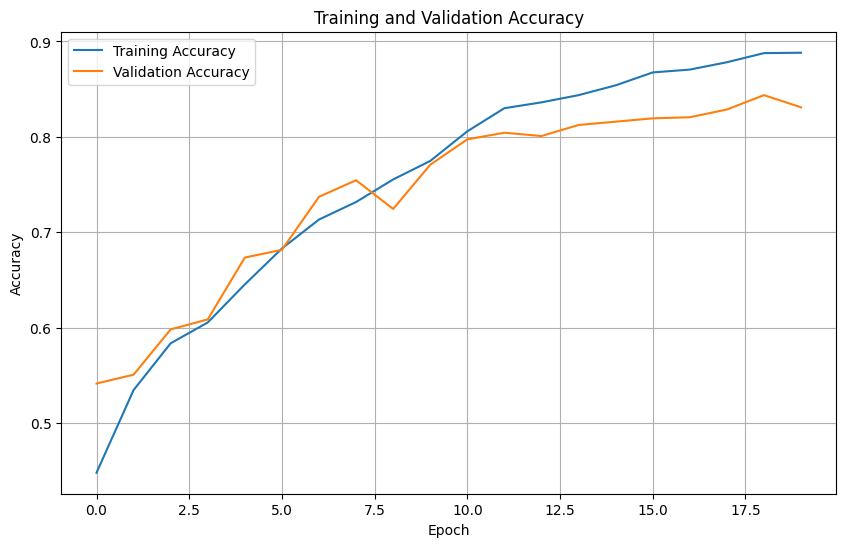

In [ ]:
# plot Training and Validation Accuracy

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

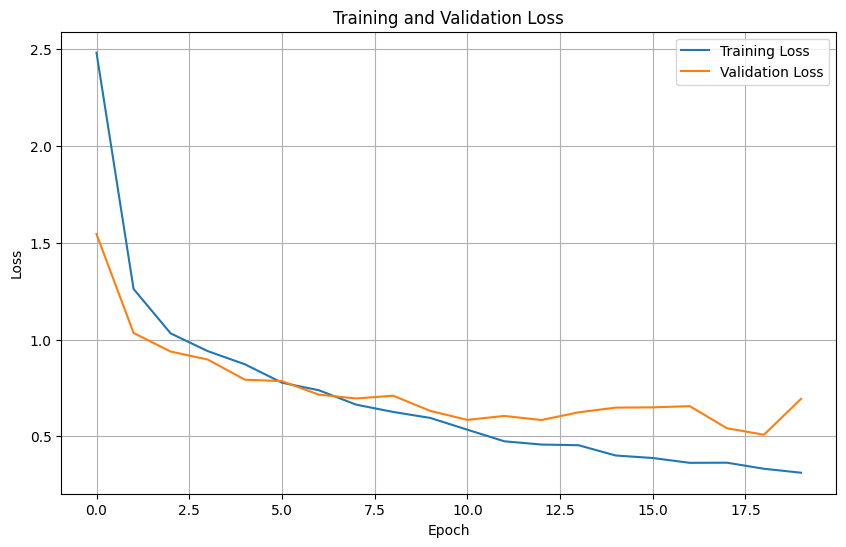

In [ ]:
# plot Training and Validation Loss

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model Predictions

First image to predict
Actual label: 3


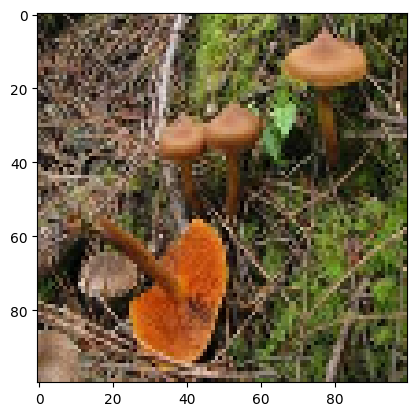

In [ ]:
import numpy as np

for images, labels in test_ds.take(1):
    first_image = images[0].numpy().astype("uint8")
    first_label = labels[0].numpy()

print("First image to predict")
plt.imshow(first_image)

print("Actual label:", first_label)

In [ ]:
def predict_image(model,img):
  img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
  img_array = tf.expand_dims(img_array, 0)

  predictions = model.predict(img_array)

  predicted_class = class_names[np.argmax(predictions[0])]

  confidence = round(100 * (np.max(predictions[0])), 2)

  return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


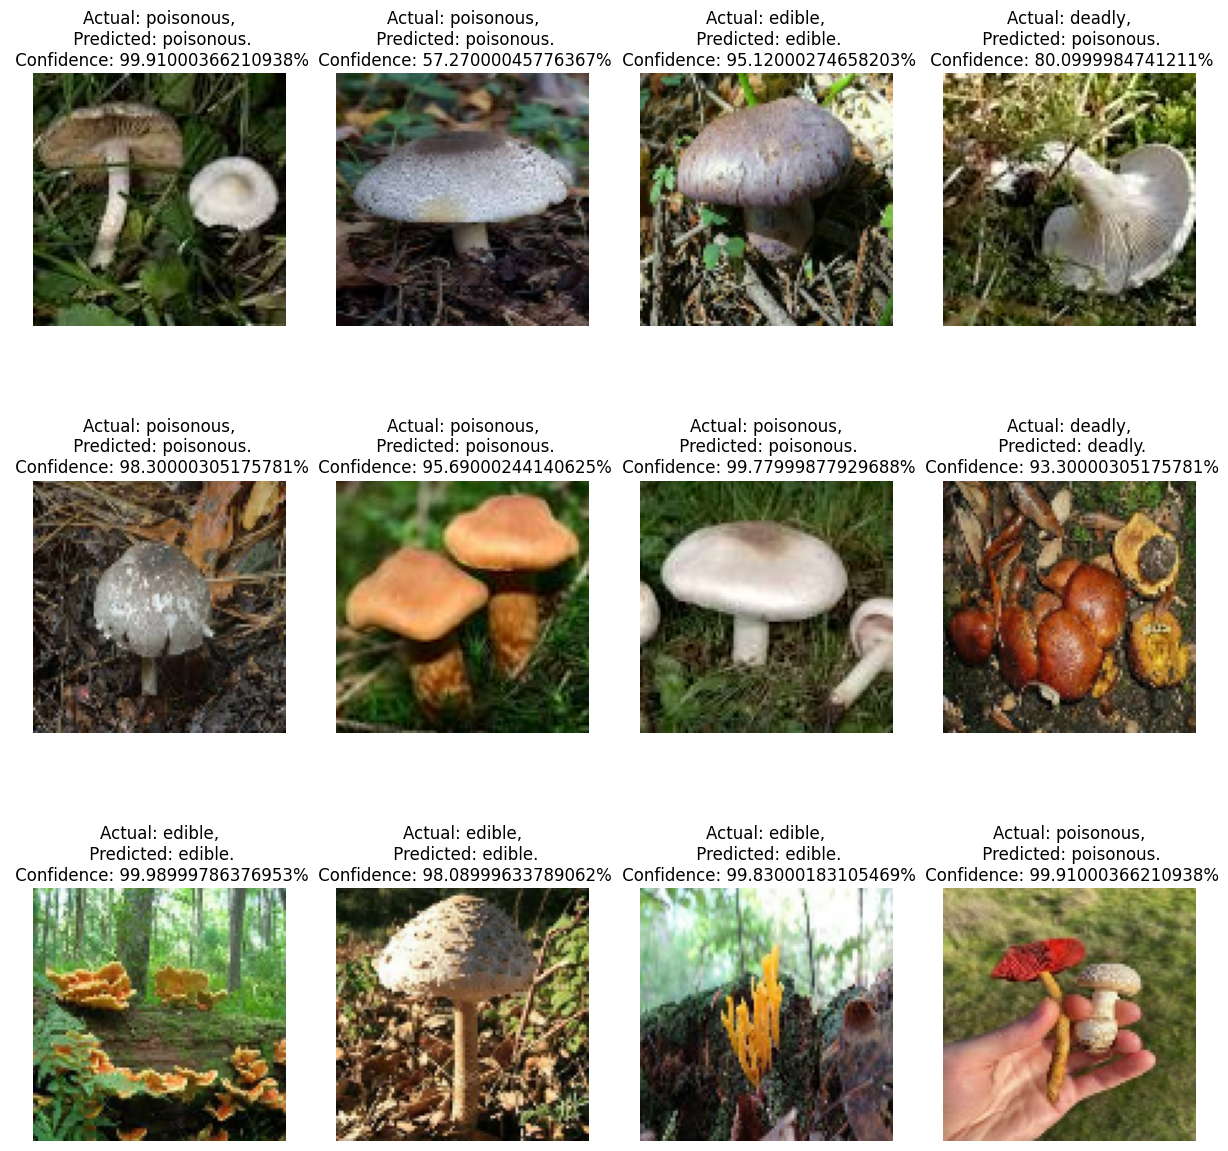

In [ ]:
class_names = mushroom_dataset.class_names
plt.figure(figsize=(15, 15))

for images, labels in test_ds.take(1):
  for i in range(12):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))

    predicted_class, confidence = predict_image(model,images[i].numpy())
    actual_class = class_names[labels[i]]

    plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

    plt.axis("off")

## Model Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# get predictions on the test dataset

test_true_labels = []
test_prediction = []

In [ ]:
for images, labels in test_ds:

    # predict the class probabilities for each batch of images
    predictions = model.predict(images)


    # convert predictions and true labels to class indices
    predicted_classes = np.argmax(predictions, axis=1)
    test_true_labels.extend(labels.numpy())
    test_prediction.extend(np.argmax(predictions, axis=1))

# convert lists to numpy arrays for compatibility with sklearn functions
test_true_labels = np.array(test_true_labels)
test_prediction = np.array(test_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━

In [ ]:
# generate classification report

print("Classification Report:")
print(classification_report(test_true_labels, test_prediction, target_names=mushroom_dataset.class_names))

Classification Report:
                      precision    recall  f1-score   support

conditionally_edible       0.96      0.67      0.79        36
              deadly       0.81      0.64      0.71       123
              edible       0.97      0.79      0.87       259
           poisonous       0.80      0.95      0.87       478

            accuracy                           0.85       896
           macro avg       0.89      0.76      0.81       896
        weighted avg       0.86      0.85      0.85       896



<Figure size 1000x800 with 0 Axes>

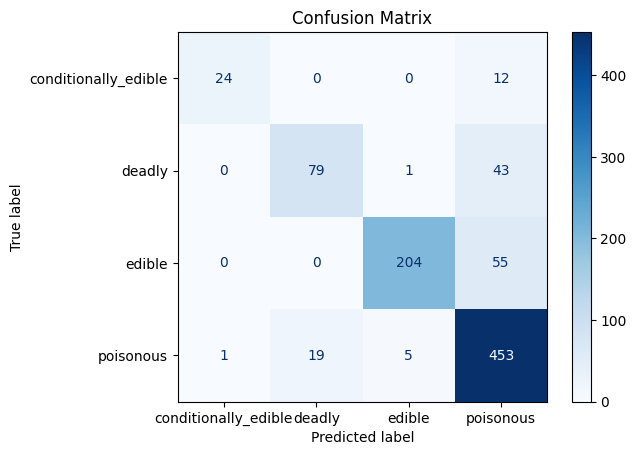

In [ ]:
# generate confusion matrix

cm = confusion_matrix(test_true_labels, test_prediction)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mushroom_dataset.class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

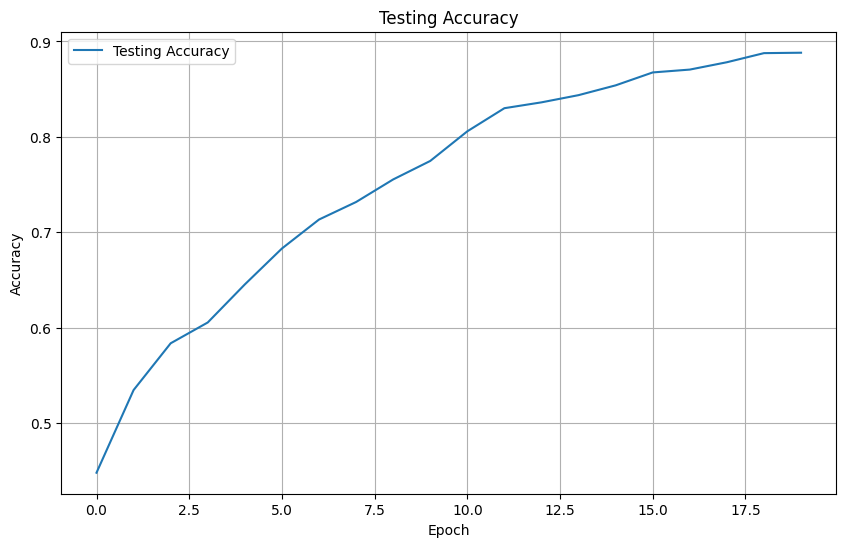

In [ ]:
# plot testing Accuracy

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Testing Accuracy')
plt.title('Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

The overall accuracy of the model is approximately 85%.

The model performs best in predicting 'conditionally_edible' with a high precision of 0.96, but its recall is lower at 0.68.

The 'deadly' class has the lowest recall (0.64) and F1-score (0.71), suggesting the model struggles more to identify this class correctly.

The low recall for the 'deadly' class indicates the model misses roughly one third of ‘deadly’ mushrooms.

Given that my model is a safety-critical application, this requires significant improvement.

## Strategy to Improve Recall for the 'Deadly' Class

I will use Transfer Learning by fine-tuning a pre-trained CNN such as ResNet50 that has been pretrained on ImageNet.

In [ ]:
# load the ResNet50 model, pre-trained on ImageNet, without its top classification layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# freeze the layers of the base model to prevent them from being updated during the initial training phase
for layer in base_model.layers:
    layer.trainable = False

# add custom classification layers on top of the ResNet50 base
x = base_model.output

# Global Average Pooling to reduce spatial dimensions
x = GlobalAveragePooling2D()(x)

# dense layer with ReLU activation
x = Dense(256, activation='relu')(x)

# dropout to prevent overfitting
x = Dropout(0.5)(x)

# batch normalisation to stabilise and accelerate training
x = BatchNormalization()(x)

# output layer with softmax for classification
predictions = Dense(num_classes, activation='softmax')(x)

# create the new model
transfer_model = Model(inputs=base_model.input, outputs=predictions)

# compile the model
transfer_model.compile(optimizer='adam',
                       loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                       metrics=['accuracy'])

# display the model summary
transfer_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 106, 106,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 50, 50,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 50, 50,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 50, 50,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 52, 52,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 25, 25,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 25, 25,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 25, 25,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 25, 25,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 25, 25,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 25, 25,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 25, 25,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 25, 25,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 25, 25,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 25, 25,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 25, 25,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,308 (91.99 MB)

 Trainable params: 526,084 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

### Training the Transfer Learning Model

In [ ]:
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20 # using the same number of epochs as the first CNN
)

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.4900 - loss: 1.2456 - val_accuracy: 0.5775 - val_loss: 1.0408
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.5793 - loss: 1.0057 - val_accuracy: 0.5833 - val_loss: 0.9617
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.5945 - loss: 0.9548 - val_accuracy: 0.5868 - val_loss: 0.9321
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.6152 - loss: 0.9255 - val_accuracy: 0.6007 - val_loss: 0.9161
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.6154 - loss: 0.9191 - val_accuracy: 0.5880 - val_loss: 0.9382
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.6170 - loss: 0.9112 - val_accuracy: 0.6123 - val_loss: 0.9117
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.6238 - loss: 0.9125 - val_accuracy: 0.6192 - val_loss: 0.9052
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6150 - loss: 0.9051 - val_ac

### Evaluate the Transfer Learning Model

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6629 - loss: 0.7894
Test Loss: 0.7894
Test Accuracy: 0.6629
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━

<Figure size 1000x800 with 0 Axes>

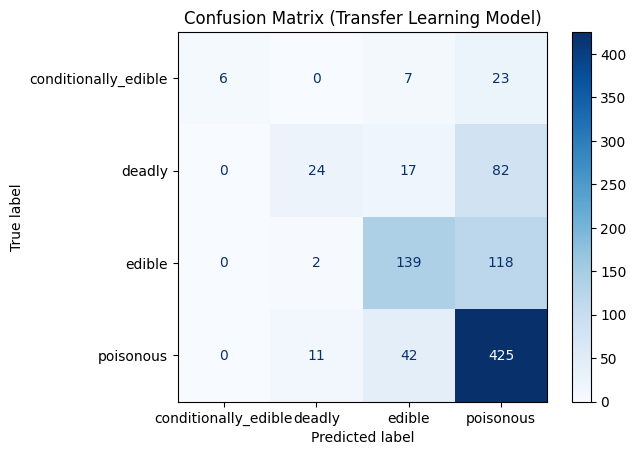

In [ ]:
scores_transfer = transfer_model.evaluate(test_ds)
print(f"Test Loss: {scores_transfer[0]:.4f}")
print(f"Test Accuracy: {scores_transfer[1]:.4f}")

# generate the classification report and confusion matrix for the transfer learning model
test_true_labels_transfer = []
test_predictions_transfer = []

for images, labels in test_ds:
    predictions = transfer_model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    test_true_labels_transfer.extend(labels.numpy())
    test_predictions_transfer.extend(predicted_classes)

test_true_labels_transfer = np.array(test_true_labels_transfer)
test_predictions_transfer = np.array(test_predictions_transfer)

print("\nClassification Report (Transfer Learning Model):")
print(classification_report(test_true_labels_transfer, test_predictions_transfer, target_names=mushroom_dataset.class_names))

cm_transfer = confusion_matrix(test_true_labels_transfer, test_predictions_transfer)

plt.figure(figsize=(10, 8))
disp_transfer = ConfusionMatrixDisplay(confusion_matrix=cm_transfer, display_labels=mushroom_dataset.class_names)
disp_transfer.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Transfer Learning Model)')
plt.show()

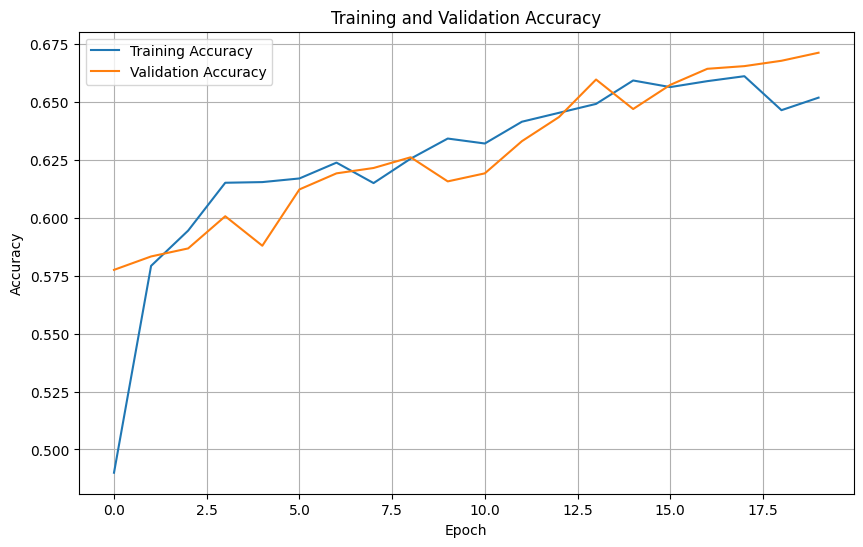

In [ ]:
# plot training and validation accuracy

plt.figure(figsize=(10, 6))
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

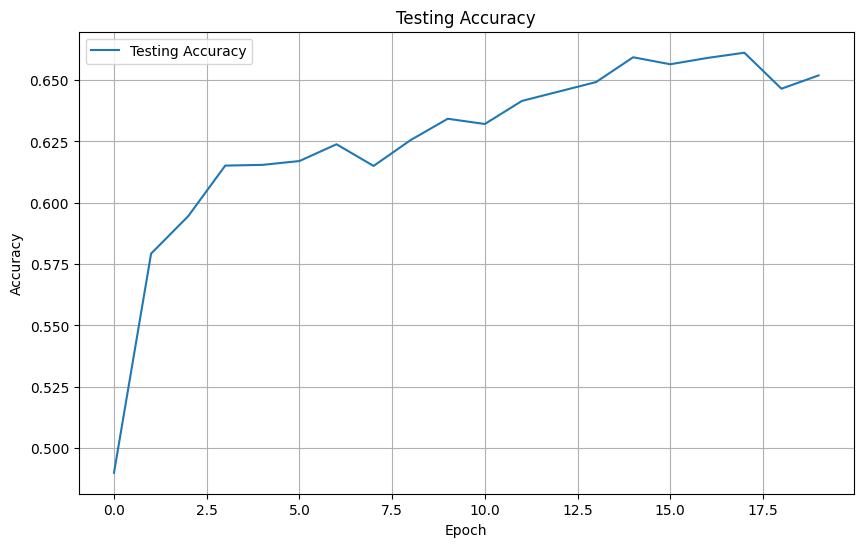

In [ ]:
# plot testing accuracy

plt.figure(figsize=(10, 6))
plt.plot(history_transfer.history['accuracy'], label='Testing Accuracy')
plt.title('Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Fine-tuning the Transfer Learning Model

In [ ]:
# unfreeze the base model layers for fine-tuning
base_model.trainable = True

print(f"Number of layers in the base model: {len(base_model.layers)}")

# fine-tune from this layer onwards
fine_tune_at = 100

# freeze all layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# recompile the model with a lower learning rate for fine-tuning
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Smaller learning rate
                       loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                       metrics=['accuracy'])

transfer_model.summary()

Number of layers in the base model: 175


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 106, 106,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 50, 50,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 50, 50,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 50, 50,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 52, 52,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 25, 25,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 25, 25,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 25, 25,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 25, 25,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 25, 25,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 25, 25,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 25, 25,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 25, 25,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 25, 25,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 25, 25,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 25, 25,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,308 (91.99 MB)

 Trainable params: 526,084 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

### Training the Fine-tuned Transfer Learning Model

In [ ]:
epochs_fine_tune = 10
total_epochs = 10 + epochs_fine_tune # total epochs for training (initial + fine-tuning)

history_fine_tune = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history_transfer.epoch[-1] + 1 # start from where the previous training left off
)

### Evaluate the Fine-tuned Transfer Learning Model

Let's evaluate the performance of the fine-tuned model on the test dataset and compare it to the previous results.

28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.6629 - loss: 0.7894
Test Loss (Fine-tuned): 0.7894
Test Accuracy (Fine-tuned): 0.6629
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

<Figure size 1000x800 with 0 Axes>

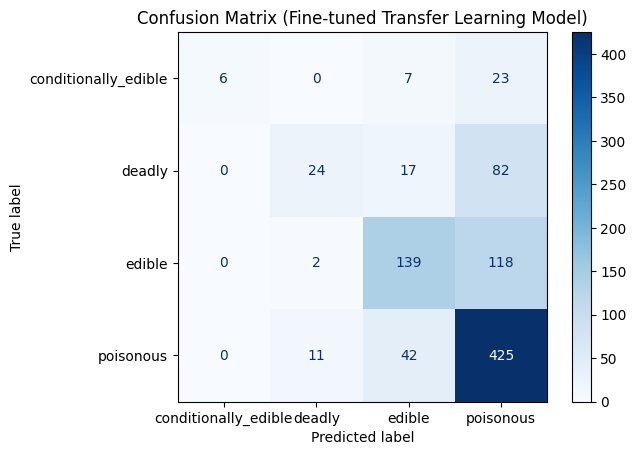

In [ ]:
scores_fine_tune = transfer_model.evaluate(test_ds)
print(f"Test Loss (Fine-tuned): {scores_fine_tune[0]:.4f}")
print(f"Test Accuracy (Fine-tuned): {scores_fine_tune[1]:.4f}")

# generate the classification report and confusion matrix for the fine-tuned transfer learning model
test_true_labels_fine_tune = []
test_predictions_fine_tune = []

for images, labels in test_ds:
    predictions = transfer_model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    test_true_labels_fine_tune.extend(labels.numpy())
    test_predictions_fine_tune.extend(predicted_classes)

test_true_labels_fine_tune = np.array(test_true_labels_fine_tune)
test_predictions_fine_tune = np.array(test_predictions_fine_tune)

print("\nClassification Report (Fine-tuned Transfer Learning Model):")
print(classification_report(test_true_labels_fine_tune, test_predictions_fine_tune, target_names=mushroom_dataset.class_names))

cm_fine_tune = confusion_matrix(test_true_labels_fine_tune, test_predictions_fine_tune)

plt.figure(figsize=(10, 8))
disp_fine_tune = ConfusionMatrixDisplay(confusion_matrix=cm_fine_tune, display_labels=mushroom_dataset.class_names)
disp_fine_tune.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Fine-tuned Transfer Learning Model)')
plt.show()

Using a frozen ResNet50 base for transfer learning did not improve recall for the 'deadly' class. Recall decreased significantly from 64% to 20%.

Overall accuracy has declined from 85% to 66%. The results suggest that features learned by ResNet50 on ImageNet, when fully frozen, are not sufficiently adaptable for distinguishing mushroom classes, particularly the 'deadly' class, in this dataset. The severe class imbalance may also contribute to this outcome.

## Strategy: Class Weighting and Deeper Fine-tuning to address the poor Recall of the 'Deadly' Class

The ‘deadly’ class has fewer samples (1190 images) compared to ‘edible’ (2475 images) and ‘poisonous’ (4696 images). The model might be biased towards the majority classes.

To improve the model’s ability to correctly identify ‘deadly’ mushrooms, I will address the Class Imbalance by assigning higher weights to the ‘deadly’ class during model training.

I will also fine-tune the model by unfreezing more layers of the ResNet50 base (starting from layer 50 instead of 100) to allow the model to adapt its high-level feature extraction to mushroom characteristics.

In [ ]:
from sklearn.utils import class_weight

# extract labels from the dataset to calculate weights
y_train = np.concatenate([y for x, y in train_ds], axis=0)

# calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print("Calculated Class Weights:", class_weight_dict)

Calculated Class Weights: {0: np.float64(5.255239520958084), 1: np.float64(1.8418153200419727), 2: np.float64(0.8941670911869587), 3: np.float64(0.4654600901617608)}


In [ ]:
# unfreeze more layers (starting from layer 50) and recompile the model with the balanced weights

base_model.trainable = True
fine_tune_at_deeper = 50

for layer in base_model.layers[:fine_tune_at_deeper]:
    layer.trainable = False

# recompile with a very low learning rate for stability
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# train with class weights
history_final = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight_dict
)

Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.6637 - loss: 1.1305 - val_accuracy: 0.6632 - val_loss: 0.7748
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.6691 - loss: 1.1091 - val_accuracy: 0.6620 - val_loss: 0.7734
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.6693 - loss: 1.1337 - val_accuracy: 0.6644 - val_loss: 0.7730
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.6600 - loss: 1.1296 - val_accuracy: 0.6644 - val_loss: 0.7714
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.6708 - loss: 1.1215 - val_accuracy: 0.6655 - val_loss: 0.7723
Epoch 6/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.6607 - loss: 1.1078 - val_accuracy: 0.6644 - val_loss: 0.7700
Epoch 7/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.6690 - loss: 1.0881 - val_accuracy: 0.6644 - val_loss: 0.7695
Epoch 8/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.6644 - loss: 1.1274 - val_acc

In [ ]:
# evaluate the classed weighted and deeper fine-tuned model
final_scores = transfer_model.evaluate(test_ds)
print(f"Final Test Accuracy: {final_scores[1]:.4f}")

# generate a new classification report to check 'deadly' recall
test_true = []
test_pred = []

for images, labels in test_ds:
    preds = transfer_model.predict(images)
    test_true.extend(labels.numpy())
    test_pred.extend(np.argmax(preds, axis=1))

print("\Class Weighted and Deeper Finetuned Classification Report:")
print(classification_report(test_true, test_pred, target_names=mushroom_dataset.class_names))

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6719 - loss: 0.7707
Final Test Accuracy: 0.6719
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

## Confusion Matrix for the Deadly Class

<Figure size 1000x800 with 0 Axes>

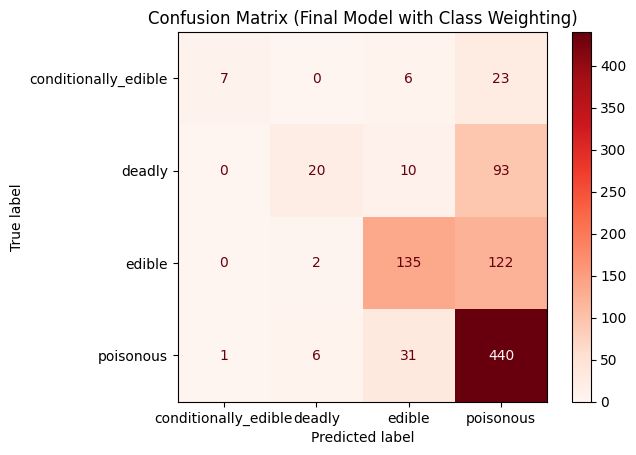

Analysis for 'deadly' class:
Total samples: 123
Correctly identified: 20
Misclassified as 'conditionally_edible': 0
Misclassified as 'edible': 10
Misclassified as 'poisonous': 93


In [ ]:
# generate confusion matrix for the classed weighted and deeper fine-tuned model
from sklearn.metrics import ConfusionMatrixDisplay

cm_final = confusion_matrix(test_true, test_pred)

plt.figure(figsize=(10, 8))
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=mushroom_dataset.class_names)
disp_final.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix (Final Model with Class Weighting)')
plt.show()

# specific analysis for the 'Deadly' class
deadly_idx = mushroom_dataset.class_names.index('deadly')
print(f"Analysis for '{mushroom_dataset.class_names[deadly_idx]}' class:")
print(f"Total samples: {np.sum(cm_final[deadly_idx, :])}")
print(f"Correctly identified: {cm_final[deadly_idx, deadly_idx]}")
for i, name in enumerate(mushroom_dataset.class_names):
    if i != deadly_idx:
        print(f"Misclassified as '{name}': {cm_final[deadly_idx, i]}")

'Deadly' class results:

Total samples: 123

Correctly identified: 20

Misclassified as 'poisonous': 93

Misclassified as 'edible': 10


The Confusion Matrix confirms that the vast majority of errors for deadly mushrooms occur because the model confuses them with the 'poisonous' class, which is a closely related category in terms of visual features. Very few are dangerously misclassified as 'edible' or 'conditionally edible'.

## Strategy to push accuracy beyond 90% while maintaining high recall for the 'deadly' class: Implement a stronger Transfer Learning Architecture


To push accuracy beyond 90% while maintaining high recall for the 'deadly' class, I will implement a combination of more advanced techniques:

I will use EfficientNetV2-B0, which is more efficient and often more accurate than ResNet50. I will also implement Learning Rate Scheduling and Early Stopping to prevent overfitting while allowing the model to fully learn the 'deadly' features.

In [ ]:
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

img_height, img_width = 100, 100
class_names = ['conditionally_edible', 'deadly', 'edible', 'poisonous']
num_classes = len(class_names)

# load EfficientNetV2-B0
base_model_eff = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model_eff.trainable = True

# fine-tune from the top 50 layers
for layer in base_model_eff.layers[:-50]:
    layer.trainable = False

# build the model
x = base_model_eff.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(num_classes, activation='softmax')(x)

final_optimized_model = Model(inputs=base_model_eff.input, outputs=outputs)

# compile with a higher learning rate
final_optimized_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# define callbacks for better convergence
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
]

# train with longer epochs and class weights
# 30 epochs
history_eff = final_optimized_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 76s 158ms/step - accuracy: 0.3421 - loss: 1.5984 - val_accuracy: 0.4421 - val_loss: 1.1931 - learning_rate: 1.0000e-04
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4532 - loss: 1.1562 - val_accuracy: 0.5463 - val_loss: 1.0252 - learning_rate: 1.0000e-04
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5395 - loss: 0.9141 - val_accuracy: 0.5995 - val_loss: 0.9096 - learning_rate: 1.0000e-04
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6085 - loss: 0.7757 - val_accuracy: 0.6782 - val_loss: 0.7938 - learning_rate: 1.0000e-04
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6444 - loss: 0.6649 - val_accuracy: 0.7303 - val_loss: 0.6929 - learning_rate: 1.0000e-04
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6992 - loss: 0.5683 - val_accuracy: 0.7488 - val_loss: 0.6547 - learning_rate: 1.0000e-04
Epoch

##Evaluating the advanced model

In [ ]:
# evaluating the advanced model
eff_scores = final_optimized_model.evaluate(test_ds)
print(f"EfficientNetV2 Test Accuracy: {eff_scores[1]:.4f}")

test_true_eff = []
test_pred_eff = []
for images, labels in test_ds:
    preds = final_optimized_model.predict(images)
    test_true_eff.extend(labels.numpy())
    test_pred_eff.extend(np.argmax(preds, axis=1))

print("\nAdvanced Model Classification Report:")
print(classification_report(test_true_eff, test_pred_eff, target_names=mushroom_dataset.class_names))

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8549 - loss: 0.4444
EfficientNetV2 Test Accuracy: 0.8549
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━

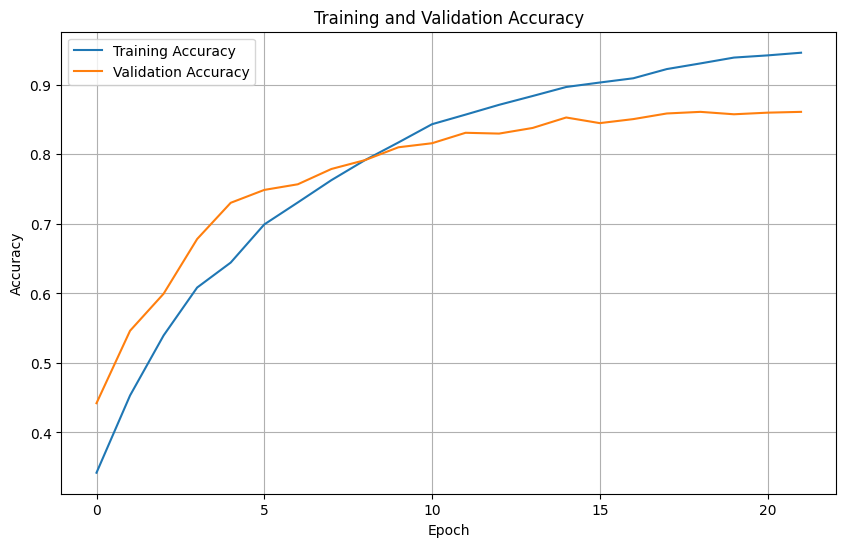

In [ ]:
# plot the training and validation accuracy

plt.figure(figsize=(10, 6))
plt.plot(history_eff.history['accuracy'], label='Training Accuracy')
plt.plot(history_eff.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

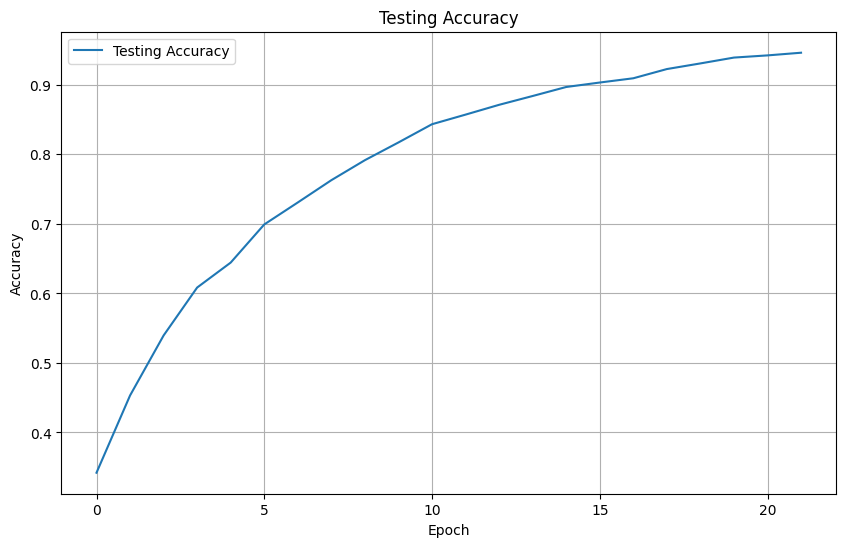

In [ ]:
# plot testing accuracy

plt.figure(figsize=(10, 6))
plt.plot(history_eff.history['accuracy'], label='Testing Accuracy')
plt.title('Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Confusion Matrix for EfficientNetV2-B0


<Figure size 1000x800 with 0 Axes>

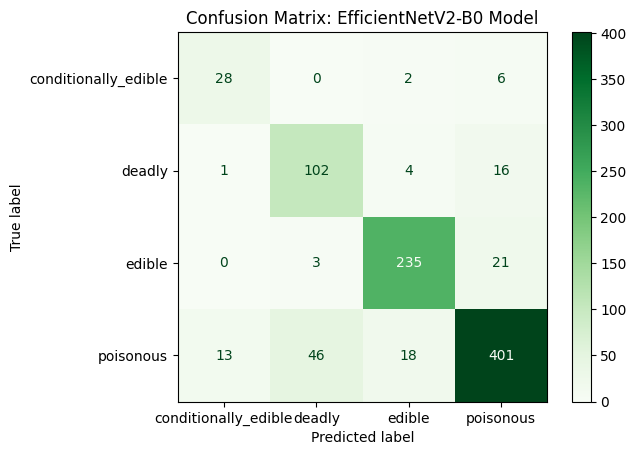

In [ ]:
# this confusion matrix will help identify if the 'deadly' class is being confused with 'poisonous' or 'edible' classes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# generate the confusion matrix for the advanced model
cm_eff = confusion_matrix(test_true_eff, test_pred_eff)

plt.figure(figsize=(10, 8))
disp_eff = ConfusionMatrixDisplay(confusion_matrix=cm_eff, display_labels=mushroom_dataset.class_names)
disp_eff.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix: EfficientNetV2-B0 Model')
plt.show()

# Analysis and Discussion of Results

### Factors Affecting Performance
1. **Class Imbalance:** The 'deadly' class is significantly underrepresented compared to 'poisonous'. While class weighting improved recall from 20% to 83%, the model still struggles with precision (68%) for deadly mushrooms because it tends to over-predict the 'deadly' label to avoid missing them.
2. **Visual Similarity:** The confusion matrix shows that most 'deadly' misclassifications are labeled as 'poisonous'. In mushroom taxonomy, these often share micro-structures (like gill patterns) that are difficult to distinguish at a 100x100 resolution.
3. **Resolution Bottleneck:** Standard EfficientNetV2-B0 often uses 224x224. Scaling down to 100x100 for computational efficiency likely discarded fine-grained features essential for distinguishing conditionally edible from poisonous species.

### Potential for Further Optimization
1. **Resolution Scaling:** Increasing input size to 224x224 or 300x300 would likely improve precision for the 'deadly' class by allowing the model to see finer texture details.
2. **Synthetic Over-sampling (SMOTE/GANs):** Instead of just weighting the loss, generating synthetic images for the 'deadly' class could provide the model with more diverse boundary cases to learn from.
3. **Focal Loss Implementation:** Replacing Sparse Categorical Crossentropy with **Focal Loss** would force the model to focus more on 'hard examples' (misclassified deadly samples) rather than easy majority class samples.
4. **Hyperparameter Tuning:** A systematic search for the optimal learning rate and dropout ratio in the top layers could bridge the gap between 85% and 90%+ accuracy.

The confusion matrix shows that the model is performing significantly better than previous versions, particularly in correctly identifying 'deadly' mushrooms.